# Unsupervised Fraud Detection — One-Class SVM Anomaly Scoring

Fit One-Class SVM on unlabeled (`unknown`) records. Use the negated decision
function as an anomaly score. Flag the top 1% most anomalous points as
suspected fraud.

> **Note:** `unknown ≠ normal`. The training set may contain hidden fraud cases,
> which slightly blurs the model's view of normal behaviour.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy import sparse

from sklearn.svm import OneClassSVM
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 2. Config

In [2]:
# Paths & labels 
DATA_PATH   = "fraud_data_encoded_v2.csv"
LABEL_COL   = "fraud"
TRAIN_LABEL = "unknown"
TEST_LABEL  = "fraud"

# Model hyperparameters 
RANDOM_STATE            = 42
OCSVM_KERNEL            = "rbf"
OCSVM_NU                = 0.01   # upper bound on fraction of training outliers
OCSVM_GAMMA             = "scale"
OCSVM_ANOMALY_QUANTILE  = 0.99   # top 1% most anomalous flagged

# Feature selection thresholds 
MAX_CATEGORICAL_LEVELS = 30     # drop categorical columns with more unique values than this
MAX_CATEGORICAL_RATIO  = 0.05   # drop if unique_count / n_rows exceeds this ratio
MAX_MISSING_RATE       = 0.98   # drop columns that are more than 98% missing
SVD_MAX_COMPONENTS     = 50     # max SVD components when compressing sparse OHE output

# String flag columns → convert to 0/1 before modeling 
FLAG_MAPPINGS = {
    "ocr_tampering_flag":         {"yes": 1, "no": 0},
    "front_liveness_fakeprint":   {"true": 1, "false": 0},
    "back_liveness_fakeprint":    {"true": 1, "false": 0},
    "front_object_liveness":      {"success": 1, "failure": 0},
    "back_object_liveness":       {"success": 1, "failure": 0},
    "liveness3d_object_liveness": {"success": 1, "failure": 0},
}

# Numeric columns (cast to float, impute with median) 
NUMERIC_COLS = [
    "tampering_flag",   # binary document-tampering indicator
    "year",             # year extracted from request timestamp
]

# Drop any column whose name contains one of these substrings 
DROP_NAME_KEYWORDS = [
    "uuid", "hash", "embedding", "image", "img",
    "photo", "avatar", "base64", "filepath", "filename", "sessionid",
]

# Drop these specific columns regardless of other rules 
MANUAL_DROP_COLS = [
    "tokenid",           # unique token per request — ID with no signal
    "ocr_cccd",          # raw OCR text from ID card — free text, high cardinality
    "finger_print",      # device fingerprint — unique per device
    "client_session",    # client session string — unique identifier
    "facecompare_uuid",  # face comparison request UUID
    "liveness3d_uuid",   # 3D liveness request UUID
    "geolite_ipaddress", # raw IP address — high cardinality; lat/lon already captured elsewhere
    "month",             # excluded: low signal after year is retained
    "day",               # excluded: low signal
    "latitude",          # excluded: noisy geolocation
    "longitude",         # excluded: noisy geolocation
    "country",
]

## 3. Helper Functions

In [3]:
def normalize_text(series):
    """Strip whitespace and lowercase a string Series."""
    return series.astype("string").str.strip().str.lower()


def safe_map(series, mapping):
    """Normalize a string Series and map values using the provided dict."""
    return normalize_text(series).map(mapping)


def preprocess_data(df):
    """
    First-pass cleaning on the raw DataFrame (no columns are dropped here):
      1. Convert FLAG_MAPPINGS columns from strings to 0/1.
      2. Cast NUMERIC_COLS to float, coercing errors to NaN.
      3. Add a `target` column (unknown=0, fraud=1) for splitting only — never used as a feature.
    """
    data = df.copy()

    for col, mapping in FLAG_MAPPINGS.items():
        if col in data.columns:
            data[col] = safe_map(data[col], mapping)

    for col in NUMERIC_COLS:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    if LABEL_COL in data.columns:
        data["target"] = normalize_text(data[LABEL_COL]).map(
            {TRAIN_LABEL: 0, TEST_LABEL: 1}
        )

    return data


def pick_feature_columns(df, label_col):
    """
    Select columns to use as model features. Drop rules applied in order:
      1. Label columns (fraud, target).
      2. Columns listed in MANUAL_DROP_COLS.
      3. Columns whose name contains a keyword from DROP_NAME_KEYWORDS.
      4. Columns with only one unique value (no signal).
      5. Columns missing >= MAX_MISSING_RATE of rows.
      6. Numeric columns → keep.
      7. Categorical columns → keep only if low-cardinality; otherwise drop.

    Returns: (kept_columns: list, dropped_info: DataFrame)
    """
    keep_cols, dropped_rows = [], []

    for col in df.columns:
        series       = df[col]
        nunique      = series.nunique(dropna=False)
        missing_rate = series.isna().mean()
        unique_ratio = nunique / len(df)

        if col in {label_col, "target"}:
            dropped_rows.append({"column": col, "reason": "label"})
        elif col in MANUAL_DROP_COLS:
            dropped_rows.append({"column": col, "reason": "manual_drop"})
        elif any(kw in col.lower() for kw in DROP_NAME_KEYWORDS):
            dropped_rows.append({"column": col, "reason": "name_rule"})
        elif nunique <= 1:
            dropped_rows.append({"column": col, "reason": "single_value"})
        elif missing_rate >= MAX_MISSING_RATE:
            dropped_rows.append({"column": col, "reason": "too_many_missing"})
        elif pd.api.types.is_numeric_dtype(series):
            keep_cols.append(col)
        elif nunique <= MAX_CATEGORICAL_LEVELS and unique_ratio <= MAX_CATEGORICAL_RATIO:
            keep_cols.append(col)
        else:
            dropped_rows.append({"column": col, "reason": "high_cardinality_text"})

    dropped_df = (
        pd.DataFrame(dropped_rows)
        .sort_values(["reason", "column"])
        .reset_index(drop=True)
    )
    return keep_cols, dropped_df


def make_preprocessor(df, feature_cols):
    """
    Build a ColumnTransformer with two sub-pipelines:
      - numeric:     median imputation → StandardScaler
      - categorical: fill 'missing' → OneHotEncoder (ignore unknown categories)

    Returns: (preprocessor, numeric_cols, categorical_cols)
    """
    numeric_cols     = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe,     numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )
    return preprocessor, numeric_cols, categorical_cols


def make_dense_representation(X_train, X_test, max_components=50, random_state=42):
    """
    Convert preprocessor output to a dense float matrix ready for One-Class SVM.
      - Sparse input (from OHE): apply TruncatedSVD → StandardScaler.
      - Dense input:             apply StandardScaler only.

    Returns: (X_train_dense, X_test_dense, info_dict)
    """
    if sparse.issparse(X_train):
        max_valid = min(X_train.shape[0] - 1, X_train.shape[1] - 1, max_components)
        if max_valid >= 2:
            svd            = TruncatedSVD(n_components=max_valid, random_state=random_state)
            X_train_dense  = svd.fit_transform(X_train)
            X_test_dense   = svd.transform(X_test)
            scaler         = StandardScaler()
            X_train_dense  = scaler.fit_transform(X_train_dense)
            X_test_dense   = scaler.transform(X_test_dense)
            info = {"used_svd": True,  "n_components": max_valid,
                    "input_dim": X_train.shape[1], "output_dim": X_train_dense.shape[1]}
            return X_train_dense, X_test_dense, info
        X_train_dense = X_train.toarray()
        X_test_dense  = X_test.toarray()
    else:
        X_train_dense = np.asarray(X_train)
        X_test_dense  = np.asarray(X_test)

    scaler        = StandardScaler()
    X_train_dense = scaler.fit_transform(X_train_dense)
    X_test_dense  = scaler.transform(X_test_dense)
    info = {"used_svd": False, "n_components": None,
            "input_dim": X_train_dense.shape[1], "output_dim": X_train_dense.shape[1]}
    return X_train_dense, X_test_dense, info

## 4. Load Data & Split

The split is label-based, but the label is **never passed to the model**.

| Split | Rows |
|---|---|
| Train | all `unknown` |
| Test  | all `fraud`   |

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df     = preprocess_data(df_raw)

label_counts = (
    normalize_text(df[LABEL_COL])
    .value_counts(dropna=False)
    .rename_axis(LABEL_COL)
    .reset_index(name="count")
)
display(label_counts)

train_mask = normalize_text(df[LABEL_COL]) == TRAIN_LABEL
test_mask  = normalize_text(df[LABEL_COL]) == TEST_LABEL

train_df = df.loc[train_mask].copy()
test_df  = df.loc[test_mask].copy()

print(f"Full dataset : {df.shape}")
print(f"Train        : {train_df.shape}  (label = '{TRAIN_LABEL}')")
print(f"Test         : {test_df.shape}  (label = '{TEST_LABEL}')")

,fraud,count
0,unknown,31293
1,fraud,39


Full dataset : (31332, 46)
Train        : (31293, 46)  (label = 'unknown')
Test         : (39, 46)  (label = 'fraud')


## 5. Feature Selection

Conservative rules to exclude ID-like, high-cardinality, nearly-empty, and
leak-prone columns. See `pick_feature_columns` in the helpers section for the
full drop logic.

In [5]:
feature_cols, dropped_feature_info = pick_feature_columns(train_df, LABEL_COL)

print(f"Features kept : {len(feature_cols)}")
print(f"Features dropped : {len(dropped_feature_info)}")
print()

display(pd.DataFrame({"feature_col": feature_cols}))
display(dropped_feature_info)

if len(feature_cols) == 0:
    raise ValueError("No feature columns left. Loosen the feature selection rules in Config.")

Features kept : 14
Features dropped : 32



,feature_col
0,req_path
1,req_timestamplog
2,res_timestamplog
3,ocr_tampering_flag
4,front_liveness_fakeprint
5,front_object_liveness
6,liveness_timestamplog_front
7,liveness_timestamplog_back
8,back_liveness_fakeprint
9,back_object_liveness


,column,reason
0,city,high_cardinality_text
1,flag_123456,high_cardinality_text
2,ipaddress,high_cardinality_text
3,ma_may,high_cardinality_text
4,os_version,high_cardinality_text
5,fraud,label
6,target,label
7,client_session,manual_drop
8,country,manual_drop
9,day,manual_drop


## 6. Preprocessing

Build numeric and categorical pipelines, fit on train, then apply the same
transform to test. Reduce dimensionality with TruncatedSVD if the OHE output
is sparse.

In [6]:
X_train_df = train_df[feature_cols].copy()
X_test_df  = test_df[feature_cols].copy()

preprocessor, numeric_cols, categorical_cols = make_preprocessor(train_df, feature_cols)

X_train_pre = preprocessor.fit_transform(X_train_df)
X_test_pre  = preprocessor.transform(X_test_df)

X_train_model, X_test_model, dim_info = make_dense_representation(
    X_train_pre, X_test_pre,
    max_components=SVD_MAX_COMPONENTS,
    random_state=RANDOM_STATE,
)

print(f"Numeric columns     : {len(numeric_cols)}")
print(f"Categorical columns : {len(categorical_cols)}")
print(f"Dimension info      : {dim_info}")
print(f"Train matrix shape  : {X_train_model.shape}")
print(f"Test matrix shape   : {X_test_model.shape}")

Numeric columns     : 13
Categorical columns : 1
Dimension info      : {'used_svd': False, 'n_components': None, 'input_dim': 15, 'output_dim': 15}
Train matrix shape  : (31293, 15)
Test matrix shape   : (39, 15)


## 7. One-Class SVM Training

Fit on the train set only. The anomaly score for each sample is the **negated
decision function** — larger value = further outside the learned boundary =
more unusual.

`decision_function` sign convention (sklearn):
- positive → inside boundary (inlier)
- negative → outside boundary (outlier / anomaly)

Negating keeps the same convention as the KMeans version: **higher score =
more anomalous**.

In [7]:
ocsvm = OneClassSVM(kernel=OCSVM_KERNEL, nu=OCSVM_NU, gamma=OCSVM_GAMMA)
ocsvm.fit(X_train_model)

train_score = -ocsvm.decision_function(X_train_model)   # higher → more anomalous
test_score  = -ocsvm.decision_function(X_test_model)

### Train Set Anomaly Score Projection (PCA 2D)

Project the training data to 2D via PCA. Points are coloured by anomaly score
(deep red = most anomalous) for a visual sanity-check of the model's behaviour.

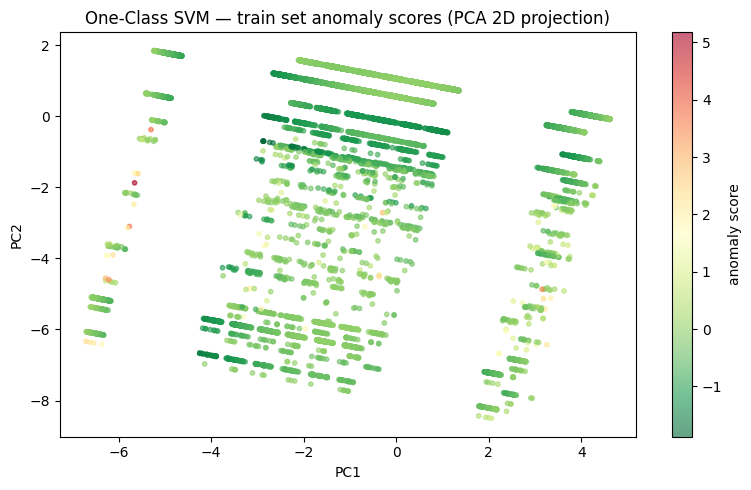

In [8]:
pca    = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_train_model)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=train_score, cmap="RdYlGn_r",
    s=10, alpha=0.6,
)
plt.colorbar(scatter, ax=ax, label="anomaly score")
ax.set_title("One-Class SVM — train set anomaly scores (PCA 2D projection)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

## 8. Threshold & Predictions

The anomaly threshold is the 99th percentile of train scores. No test labels
are used to derive it.

In [9]:
threshold = float(np.quantile(train_score, OCSVM_ANOMALY_QUANTILE))

ocsvm_pred_train = (train_score > threshold).astype(int)
ocsvm_pred_test  = (test_score  > threshold).astype(int)

print(f"Threshold (q={OCSVM_ANOMALY_QUANTILE}) : {threshold:.4f}")
print(f"Train flagged : {ocsvm_pred_train.sum():>5} / {len(ocsvm_pred_train)}  ({ocsvm_pred_train.mean():.2%})")
print(f"Test  flagged : {ocsvm_pred_test.sum():>5} / {len(ocsvm_pred_test)}   ({ocsvm_pred_test.mean():.2%})")

Threshold (q=0.99) : 0.0003
Train flagged :   313 / 31293  (1.00%)
Test  flagged :    39 / 39   (100.00%)


## 9. Evaluation — Recall on Confirmed Fraud

In [10]:
n_fraud = len(test_score)
caught  = int(ocsvm_pred_test.sum())
print(f"Recall on {n_fraud} confirmed fraud cases: {caught}/{n_fraud} = {caught/n_fraud:.1%}")

Recall on 39 confirmed fraud cases: 39/39 = 100.0%


### Anomaly Score Distribution

Overlay the train and test score distributions. Fraud cases should concentrate
at higher scores, to the right of the threshold.

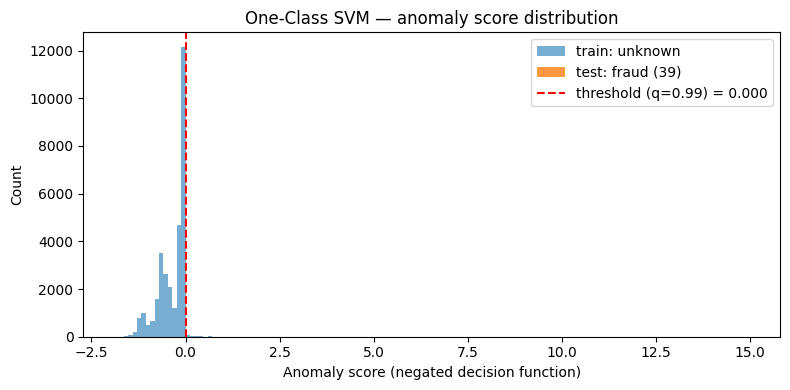

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_score, bins=60, alpha=0.6, label="train: unknown")
ax.hist(test_score,  bins=20, alpha=0.8, label=f"test: fraud ({n_fraud})")
ax.axvline(threshold, color="red", linestyle="--",
           label=f"threshold (q={OCSVM_ANOMALY_QUANTILE}) = {threshold:.3f}")
ax.set_xlabel("Anomaly score (negated decision function)")
ax.set_ylabel("Count")
ax.set_title("One-Class SVM — anomaly score distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Export Scored Records

Export all rows with their anomaly score and flag column, in the original raw
format. `ocsvm_flagged = 1` means the row exceeded the quantile threshold.

In [12]:
train_scored_raw = df_raw.loc[train_df.index].copy()
train_scored_raw["ocsvm_anomaly_score"] = train_score
train_scored_raw["ocsvm_flagged"]       = ocsvm_pred_train
train_scored_raw.to_csv("train_scored_ocsvm.csv", index=False)
print(f"Exported {len(train_scored_raw)} train rows → train_scored_ocsvm.csv")
print(f"  flagged: {ocsvm_pred_train.sum()} ({ocsvm_pred_train.mean():.2%})")

test_scored_raw = df_raw.loc[test_df.index].copy()
test_scored_raw["ocsvm_anomaly_score"] = test_score
test_scored_raw["ocsvm_flagged"]       = ocsvm_pred_test
test_scored_raw.to_csv("test_scored_ocsvm.csv", index=False)
print(f"Exported {len(test_scored_raw)} test rows  → test_scored_ocsvm.csv")
print(f"  flagged: {ocsvm_pred_test.sum()} ({ocsvm_pred_test.mean():.2%})")

Exported 31293 train rows → train_scored_ocsvm.csv
  flagged: 313 (1.00%)
Exported 39 test rows  → test_scored_ocsvm.csv
  flagged: 39 (100.00%)


## 11. Feature Importance Analysis

### A. Per-feature Anomaly Impact (OCSVM)

For each feature, shuffle it across the group's rows and measure the drop in
the group's mean anomaly score vs the baseline:

```
impact_j = mean_score_baseline − mean_score_when_feature_j_is_shuffled
```

Larger drop → feature contributes more to the anomaly score for that group.
Computed separately for two groups (mirroring the KMeans centroid-contribution
analysis):

- **All confirmed fraud** rows in the test set
- **Flagged anomalies only** (those that crossed the threshold)

In [13]:
def get_transformed_feature_names(preprocessor, numeric_cols, categorical_cols):
    """Recover feature names from the fitted ColumnTransformer."""
    names = list(numeric_cols)
    ohe   = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    names += list(ohe.get_feature_names_out(categorical_cols))
    return np.array(names)


def compute_ocsvm_impact(X, ocsvm_model, n_repeats=5, random_state=42):
    """
    For each feature column j, shuffle it n_repeats times and return the mean
    drop in the group mean anomaly score vs the baseline.
    Returns a 1-D array of length n_features (one value per transformed feature).
    """
    rng           = np.random.default_rng(random_state)
    baseline_mean = -ocsvm_model.decision_function(X).mean()
    impacts       = np.zeros(X.shape[1])

    for j in range(X.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_perm       = X.copy()
            perm_idx     = rng.permutation(X_perm.shape[0])
            X_perm[:, j] = X_perm[perm_idx, j]
            drops.append(baseline_mean - (-ocsvm_model.decision_function(X_perm).mean()))
        impacts[j] = np.mean(drops)

    return impacts


def original_feature_name(transformed_name, numeric_cols):
    """Map a transformed feature name back to its original column name."""
    if transformed_name in numeric_cols:
        return transformed_name
    if "__" in transformed_name:           # OneHotEncoder format: col__value
        return transformed_name.split("__")[0]
    return transformed_name


# Compute impacts 
transformed_names = get_transformed_feature_names(preprocessor, numeric_cols, categorical_cols)

impact_all     = compute_ocsvm_impact(X_test_model, ocsvm)
impact_flagged = (
    compute_ocsvm_impact(X_test_model[ocsvm_pred_test == 1], ocsvm)
    if ocsvm_pred_test.sum() > 0 else impact_all
)

# Build feature-level table 
impact_df = pd.DataFrame({
    "transformed_feature":   transformed_names,
    "mean_impact_all_fraud": impact_all,
    "mean_impact_flagged":   impact_flagged,
})
impact_df["original_feature"] = impact_df["transformed_feature"].apply(
    lambda n: original_feature_name(n, list(numeric_cols))
)
impact_df = impact_df.sort_values("mean_impact_all_fraud", ascending=False).reset_index(drop=True)

print("Top 30 transformed features by mean anomaly impact")
display(impact_df.head(30))

# Collapse to original feature level 
orig_impact = (
    impact_df
    .groupby("original_feature", sort=False)
    .agg(
        impact_all_fraud=("mean_impact_all_fraud", "sum"),
        impact_flagged  =("mean_impact_flagged",   "sum"),
    )
    .sort_values("impact_all_fraud", ascending=False)
    .reset_index()
)

print("\nTop 20 original features by total anomaly impact")
display(orig_impact.head(20))

Top 30 transformed features by mean anomaly impact


,transformed_feature,mean_impact_all_fraud,mean_impact_flagged,original_feature
0,liveness_timestamplog_front,0.000000,0.000000,liveness_timestamplog_front
1,front_object_liveness,0.000000,0.000000,front_object_liveness
2,front_liveness_fakeprint,0.000000,0.000000,front_liveness_fakeprint
3,liveness_timestamplog_back,0.000000,0.000000,liveness_timestamplog_back
4,req_path_/ai/v1/ocr/id,0.000000,0.000000,req_path_/ai/v1/ocr/id
5,back_object_liveness,0.000000,0.000000,back_object_liveness
6,back_liveness_fakeprint,0.000000,0.000000,back_liveness_fakeprint
7,req_path_/ai/v2/ocr/id,0.000000,0.000000,req_path_/ai/v2/ocr/id
8,res_timestamplog,-0.000030,-0.000030,res_timestamplog
9,facecompare_timestamplog,-0.000040,-0.000040,facecompare_timestamplog



Top 20 original features by total anomaly impact


,original_feature,impact_all_fraud,impact_flagged
0,liveness_timestamplog_front,0.000000,0.000000
1,front_object_liveness,0.000000,0.000000
2,front_liveness_fakeprint,0.000000,0.000000
3,liveness_timestamplog_back,0.000000,0.000000
4,req_path_/ai/v1/ocr/id,0.000000,0.000000
5,back_object_liveness,0.000000,0.000000
6,back_liveness_fakeprint,0.000000,0.000000
7,req_path_/ai/v2/ocr/id,0.000000,0.000000
8,res_timestamplog,-0.000030,-0.000030
9,facecompare_timestamplog,-0.000040,-0.000040


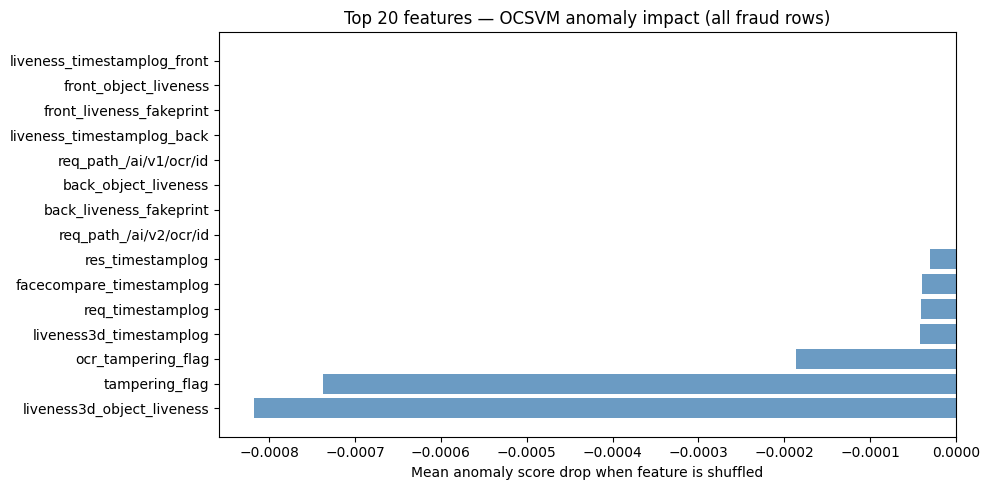

In [14]:
top_n = 20
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    orig_impact["original_feature"].iloc[:top_n][::-1],
    orig_impact["impact_all_fraud"].iloc[:top_n][::-1],
    color="steelblue", alpha=0.8,
)
ax.set_xlabel("Mean anomaly score drop when feature is shuffled")
ax.set_title(f"Top {top_n} features — OCSVM anomaly impact (all fraud rows)")
plt.tight_layout()
plt.show()

### B. Feature Distribution: Train vs Test

- **Numeric features:** mean, median, std — sorted by absolute mean difference %
- **Categorical features:** top-3 value frequencies — sorted by max frequency difference

In [15]:
train_feat_df = train_df[feature_cols].copy()
test_feat_df  = test_df[feature_cols].copy()

numeric_feat_cols     = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_df[c])]
categorical_feat_cols = [c for c in feature_cols if c not in numeric_feat_cols]

# Numeric 
num_rows = []
for col in numeric_feat_cols:
    t = pd.to_numeric(train_feat_df[col], errors="coerce").dropna()
    f = pd.to_numeric(test_feat_df[col],  errors="coerce").dropna()
    mean_diff_pct = (
        abs(f.mean() - t.mean()) / (abs(t.mean()) + 1e-9) * 100
        if len(t) > 0 and len(f) > 0 else np.nan
    )
    num_rows.append({
        "feature":         col,
        "train_mean":      t.mean(),   "test_mean":   f.mean(),
        "train_median":    t.median(), "test_median": f.median(),
        "train_std":       t.std(),    "test_std":    f.std(),
        "abs_mean_diff_%": mean_diff_pct,
    })

numeric_dist_df = (
    pd.DataFrame(num_rows)
    .sort_values("abs_mean_diff_%", ascending=False)
    .reset_index(drop=True)
)
print("Numeric features — train vs test (sorted by mean difference %)")
display(numeric_dist_df)

# Categorical 
cat_rows = []
for col in categorical_feat_cols:
    t_freq = train_feat_df[col].value_counts(normalize=True).head(3)
    f_freq = test_feat_df[col].value_counts(normalize=True).head(3)
    all_cats = set(t_freq.index) | set(f_freq.index)
    max_diff = max(abs(f_freq.get(c, 0.0) - t_freq.get(c, 0.0)) for c in all_cats)
    cat_rows.append({
        "feature":       col,
        "train_top3":    dict(t_freq.round(3)),
        "test_top3":     dict(f_freq.round(3)),
        "max_freq_diff": round(max_diff, 4),
    })

cat_dist_df = (
    pd.DataFrame(cat_rows)
    .sort_values("max_freq_diff", ascending=False)
    .reset_index(drop=True)
)

Numeric features — train vs test (sorted by mean difference %)


,feature,train_mean,test_mean,train_median,test_median,train_std,test_std,abs_mean_diff_%
0,tampering_flag,2.046784e-01,4.871795e-01,0.000000e+00,0.000000e+00,4.034728e-01,5.063697e-01,138.021977
1,back_liveness_fakeprint,9.577222e-02,0.000000e+00,0.000000e+00,0.000000e+00,2.942833e-01,0.000000e+00,99.999999
2,front_liveness_fakeprint,8.984450e-02,0.000000e+00,0.000000e+00,0.000000e+00,2.859634e-01,0.000000e+00,99.999999
3,liveness3d_object_liveness,9.164316e-01,5.384615e-01,1.000000e+00,1.000000e+00,2.767439e-01,5.050354e-01,41.243674
4,front_object_liveness,9.055481e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.924611e-01,0.000000e+00,10.430358
5,back_object_liveness,9.094366e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.869918e-01,0.000000e+00,9.958185
6,ocr_tampering_flag,9.600550e-01,9.230769e-01,1.000000e+00,1.000000e+00,1.958332e-01,2.699528e-01,3.851659
7,facecompare_timestamplog,1.762396e+12,1.760257e+12,1.762330e+12,1.760257e+12,3.348575e+08,8.564806e+06,0.121383
8,req_timestamplog,1.762396e+12,1.760257e+12,1.762330e+12,1.760257e+12,3.348613e+08,8.563439e+06,0.121383
9,res_timestamplog,1.762396e+12,1.760257e+12,1.762330e+12,1.760257e+12,3.348613e+08,8.563439e+06,0.121383


### C. Ablation Test — Feature Group Removal

Retrain One-Class SVM with one feature group removed at a time. Measure the
impact on recall.

| Group removed | Columns |
|---|---|
| liveness & tampering | all liveness / tampering columns |

In [16]:
def run_ocsvm_pipeline(train_df, test_df, feature_cols,
                       kernel=OCSVM_KERNEL, nu=OCSVM_NU, gamma=OCSVM_GAMMA,
                       quantile=OCSVM_ANOMALY_QUANTILE,
                       random_state=RANDOM_STATE, svd_max=SVD_MAX_COMPONENTS):
    """Run the full preprocess → OCSVM → threshold → recall pipeline on a given feature set."""
    if len(feature_cols) == 0:
        return {"threshold": np.nan, "flagged": 0, "recall": 0.0}

    prep, _, _ = make_preprocessor(train_df, feature_cols)
    X_tr_pre   = prep.fit_transform(train_df[feature_cols])
    X_te_pre   = prep.transform(test_df[feature_cols])

    X_tr, X_te, _ = make_dense_representation(
        X_tr_pre, X_te_pre, max_components=svd_max, random_state=random_state
    )

    oc = OneClassSVM(kernel=kernel, nu=nu, gamma=gamma)
    oc.fit(X_tr)

    tr_score = -oc.decision_function(X_tr)
    te_score = -oc.decision_function(X_te)

    thr     = float(np.quantile(tr_score, quantile))
    flagged = int((te_score > thr).sum())
    recall  = flagged / len(te_score) if len(te_score) > 0 else 0.0

    return {"threshold": round(thr, 4), "flagged": flagged, "recall": round(recall, 4)}


liveness_tampering_cols = [
    c for c in feature_cols
    if any(kw in c.lower() for kw in
           ["liveness", "tamper", "ocr", "fakeprint", "front_object", "back_object"])
]

feature_groups = {
    "baseline (all features)":      feature_cols,
    "remove: liveness & tampering": [c for c in feature_cols if c not in liveness_tampering_cols],
}

ablation_rows = []
for name, cols in feature_groups.items():
    result = run_ocsvm_pipeline(train_df, test_df, cols)
    ablation_rows.append({
        "experiment":    name,
        "n_features":    len(cols),
        "threshold":     result["threshold"],
        "flagged_fraud": result["flagged"],
        "total_fraud":   len(test_df),
        "recall":        result["recall"],
    })

ablation_df             = pd.DataFrame(ablation_rows)
baseline_recall         = ablation_df.loc[0, "recall"]
ablation_df["recall_drop"] = (baseline_recall - ablation_df["recall"]).round(4)

print("Ablation results:")
display(ablation_df)

Ablation results:


,experiment,n_features,threshold,flagged_fraud,total_fraud,recall,recall_drop
0,baseline (all features),14,0.0003,39,39,1.0,0.0
1,remove: liveness & tampering,4,0.0002,39,39,1.0,0.0


In [17]:
print(feature_groups)

{'baseline (all features)': ['req_path', 'req_timestamplog', 'res_timestamplog', 'ocr_tampering_flag', 'front_liveness_fakeprint', 'front_object_liveness', 'liveness_timestamplog_front', 'liveness_timestamplog_back', 'back_liveness_fakeprint', 'back_object_liveness', 'facecompare_timestamplog', 'liveness3d_object_liveness', 'liveness3d_timestamplog', 'tampering_flag'], 'remove: liveness & tampering': ['req_path', 'req_timestamplog', 'res_timestamplog', 'facecompare_timestamplog']}


## 12. Flagged Train Anomaly Profiles

Visual breakdown of the flagged `unknown` training rows — the points that
exceeded the 99th-percentile anomaly threshold.

All plots reuse variables already computed above (`coords`, `ocsvm_pred_train`,
`train_score`, `train_df`, `feature_cols`). No model retraining or new feature
engineering.

In [18]:
# Derive flagged subset from existing variables 
flag_mask  = ocsvm_pred_train == 1          # boolean, shape (n_train,)
flagged_df = train_df[flag_mask][feature_cols].copy()
normal_df  = train_df[~flag_mask][feature_cols].copy()
n_flagged  = int(flag_mask.sum())
n_train    = len(train_df)

# Split numeric features into binary flags vs timestamps
binary_feats = [c for c in numeric_cols
                if train_df[c].dropna().isin([0, 1]).all()]
ts_feats     = [c for c in numeric_cols if c not in binary_feats]

print(f"Flagged   : {n_flagged:>5}  ({n_flagged/n_train:.2%} of train)")
print(f"Normal    : {n_train - n_flagged:>5}  ({(n_train-n_flagged)/n_train:.2%} of train)")
print(f"Binary features   : {binary_feats}")
print(f"Timestamp features: {ts_feats}")
print(f"Categorical features: {categorical_cols}")

Flagged   :   313  (1.00% of train)
Normal    : 30980  (99.00% of train)
Binary features   : ['ocr_tampering_flag', 'front_liveness_fakeprint', 'front_object_liveness', 'back_liveness_fakeprint', 'back_object_liveness', 'liveness3d_object_liveness', 'tampering_flag']
Timestamp features: ['req_timestamplog', 'res_timestamplog', 'liveness_timestamplog_front', 'liveness_timestamplog_back', 'facecompare_timestamplog', 'liveness3d_timestamplog']
Categorical features: ['req_path']


### 12.1 PCA 2D — Flagged Anomalies vs All Train

`coords` reused from Section 7 (already computed on `X_train_model`).

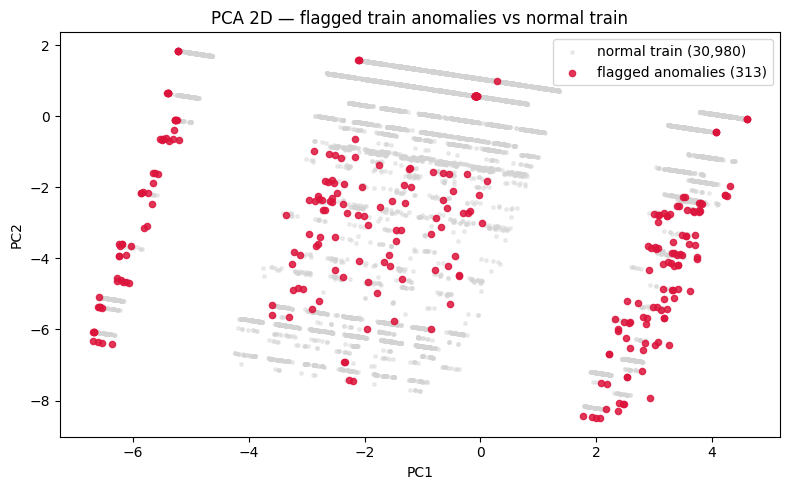

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    coords[~flag_mask, 0], coords[~flag_mask, 1],
    c="lightgrey", s=6, alpha=0.4,
    label=f"normal train ({n_train - n_flagged:,})",
)
ax.scatter(
    coords[flag_mask, 0], coords[flag_mask, 1],
    c="crimson", s=20, alpha=0.85,
    label=f"flagged anomalies ({n_flagged})",
)
ax.set_title("PCA 2D — flagged train anomalies vs normal train")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

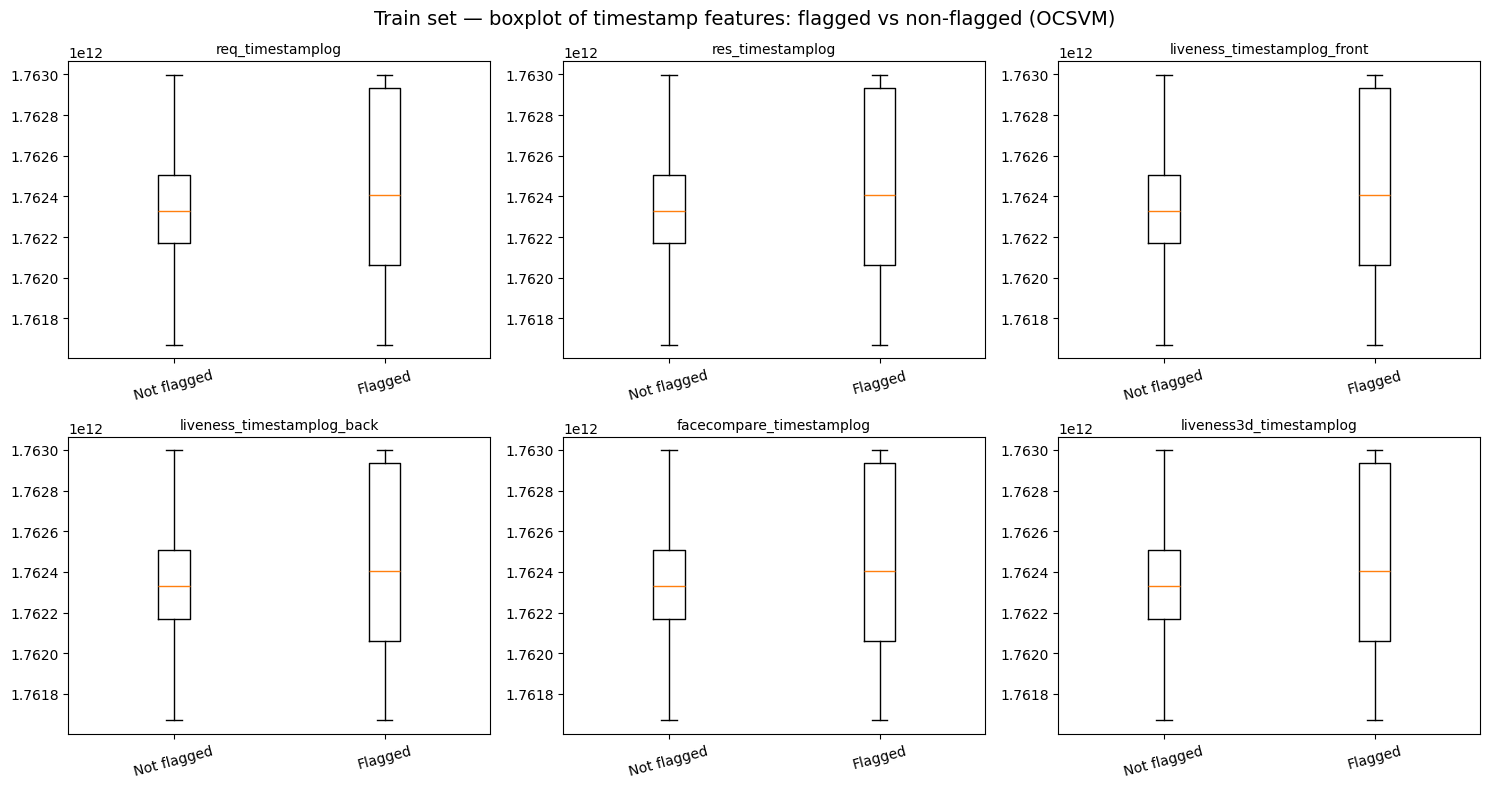

In [ ]:
# Timestamp features — boxplot comparison (normal train vs flagged)

n_ts = len(ts_feats)
n_cols = 3
n_rows = (n_ts + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(ts_feats):
    ax = axes[i]

    normal_vals = pd.to_numeric(train_df.loc[~flag_mask, col], errors="coerce").dropna().values
    flagged_vals = pd.to_numeric(train_df.loc[flag_mask, col], errors="coerce").dropna().values

    if len(normal_vals) == 0 and len(flagged_vals) == 0:
        ax.set_visible(False)
        continue

    ax.boxplot(
        [normal_vals, flagged_vals],
        labels=["Not flagged", "Flagged"],
        showfliers=False
    )
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", labelrotation=15)

for j in range(n_ts, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Train set — boxplot of timestamp features: flagged vs non-flagged (OCSVM)",
    fontsize=14
)
plt.tight_layout()
plt.show()